# 02 — RFM Customer Segmentation

Reads the `customer_rfm` table (populated by `src/rfm.py`) and visualizes segment distribution and the recency/frequency/monetary landscape.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from db import get_engine

sns.set_theme(style="whitegrid")
engine = get_engine()
pd.options.display.float_format = '{:,.2f}'.format


## Segment distribution

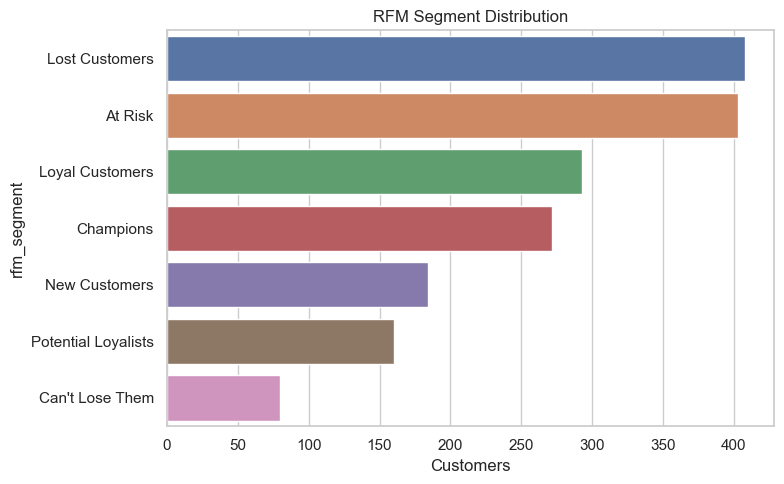

rfm_segment
Lost Customers        22.70
At Risk               22.40
Loyal Customers       16.30
Champions             15.10
New Customers         10.20
Potential Loyalists    8.90
Can't Lose Them        4.40
Name: count, dtype: float64

In [2]:
rfm = pd.read_sql('SELECT * FROM customer_rfm', engine)
seg_counts = rfm['rfm_segment'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=seg_counts.values, y=seg_counts.index, ax=ax, hue=seg_counts.index, legend=False)
ax.set_title('RFM Segment Distribution')
ax.set_xlabel('Customers')
plt.tight_layout()
plt.show()
(seg_counts / seg_counts.sum() * 100).round(1)


## Recency vs. Monetary, colored by segment

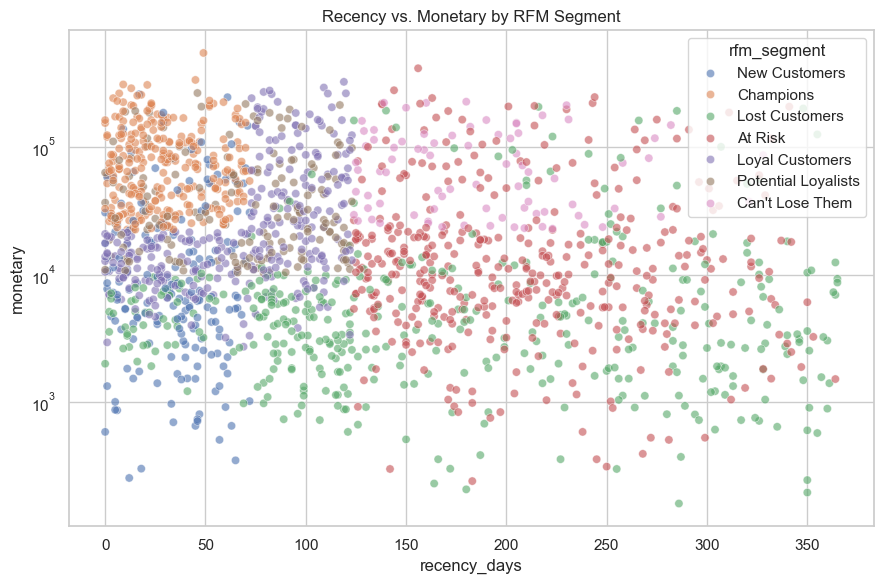

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=rfm, x='recency_days', y='monetary', hue='rfm_segment', alpha=0.6, ax=ax)
ax.set_title('Recency vs. Monetary by RFM Segment')
ax.set_yscale('log')
plt.tight_layout()
plt.show()


## Segment summary statistics

In [4]:
rfm.groupby('rfm_segment').agg(
    customers=('customer_id', 'count'),
    avg_recency_days=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
).round(1).sort_values('avg_monetary', ascending=False)


,customers,avg_recency_days,avg_frequency,avg_monetary
rfm_segment,,,,
Champions,272,30.20,4.40,"90,535.50"
Can't Lose Them,80,186.90,3.80,"80,121.40"
Potential Loyalists,160,67.40,2.20,"51,419.50"
Loyal Customers,293,66.30,3.90,"41,284.70"
At Risk,403,208.50,2.10,"28,161.20"
New Customers,184,35.60,1.50,"22,643.30"
Lost Customers,408,173.70,1.30,"11,176.40"
